# LAB 03 experiments

This notebook is a paraphrased experiment guide for the lab. Complete the calculation and prediction documents before using the output as evidence.

In [1]:
from cooccurrence import (tokenize, build_vocabulary,
    build_cooccurrence_matrix, cosine_similarity, most_similar)

toy_corpus = [
    tokenize('the cat eats fish'),
    tokenize('the dog eats fish'),
    tokenize('the cat likes milk'),
    tokenize('the dog likes meat'),
]
vocab, word_to_id = build_vocabulary(toy_corpus)
print('vocabulary:', vocab)

vocabulary: ['cat', 'dog', 'eats', 'fish', 'likes', 'meat', 'milk', 'the']


## 1. Count-based representation

For each context width, collect the matrix shape, the number of non-zero entries, and selected pair scores. Transfer the measurements—not an interpretation—into `results.csv`.

In [2]:
for width in (1, 2, 5):
    matrix = build_cooccurrence_matrix(toy_corpus, vocab, window=width)
    nnz = sum(cell != 0 for row in matrix for cell in row)
    print({'window': width, 'shape': (len(matrix), len(matrix[0])), 'nnz': nnz})
    for left, right in [('cat', 'dog'), ('cat', 'fish')]:
        score = cosine_similarity(matrix[word_to_id[left]], matrix[word_to_id[right]])
        print(left, right, score)

{'window': 1, 'shape': (8, 8), 'nnz': 18}
cat dog 1.0000000000000002
cat fish 0.4082482904638631
{'window': 2, 'shape': (8, 8), 'nnz': 30}
cat dog 0.8749999999999998
cat fish 0.2886751345948129
{'window': 5, 'shape': (8, 8), 'nnz': 36}
cat dog 0.8749999999999998
cat fish 0.6708203932499369


## 2. Nearest neighbours

Run this after writing the prediction. Preserve the returned scores and explain them later using concrete context counts.

In [3]:
matrix = build_cooccurrence_matrix(toy_corpus, vocab, window=1)
most_similar('cat', matrix, vocab, top_k=5)

[('dog', 1.0000000000000002),
 ('fish', 0.4082482904638631),
 ('meat', 0.4082482904638631),
 ('milk', 0.4082482904638631),
 ('eats', 0.0)]

## 3. Word2Vec configuration record

Use a larger course corpus for this section. Record corpus size, vocabulary, CBOW or Skip-gram objective, `vector_size`, `window`, `min_count`, `epochs`, training time, and model size. Then repeat for windows 2/5/10 and dimensions 50/100/300.

The standard API cell is intentionally left explicit so the configuration is visible in the report.

In [4]:
from gensim.models import Word2Vec
base_sentences = [
    'the doctor treated the patient at the hospital'.split(),
    'the physician examined the patient and recorded the diagnosis'.split(),
    'the clinic provides medical treatment for disease'.split(),
    'the nurse prepared the patient for surgery'.split()
]
base_model = Word2Vec(sentences=base_sentences, vector_size=50, window=2, min_count=1, sg=0, epochs=20, workers=1, seed=42)
print('Baseline Word2Vec model trained. Vocab size:', len(base_model.wv))


Baseline Word2Vec model trained. Vocab size: 20


## 4. Semantic search and error review

Represent the query `medical treatment` and documents with a documented aggregation rule. Save quantitative retrieval scores, then fill `error_analysis.md` with three successes and three surprising cases.

## 5. Matrix diagnostics and a simple plot

These cells expose the effect of context width with measured values from the selected corpus. Add your own explanation in the report files.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
matrix_rows = []
for width in (1, 2, 5):
    current = build_cooccurrence_matrix(toy_corpus, vocab, window=width)
    total = len(current) * len(current[0])
    nonzero = sum(value != 0 for row in current for value in row)
    matrix_rows.append({'window': width, 'vocab_size': len(vocab), 'total_entries': total,
                        'nonzero': nonzero, 'sparsity_percent': round(100 * (1 - nonzero / total), 2)})
matrix_stats = pd.DataFrame(matrix_rows)
matrix_stats

,window,vocab_size,total_entries,nonzero,sparsity_percent
0,1,8,64,18,71.88
1,2,8,64,30,53.12
2,5,8,64,36,43.75


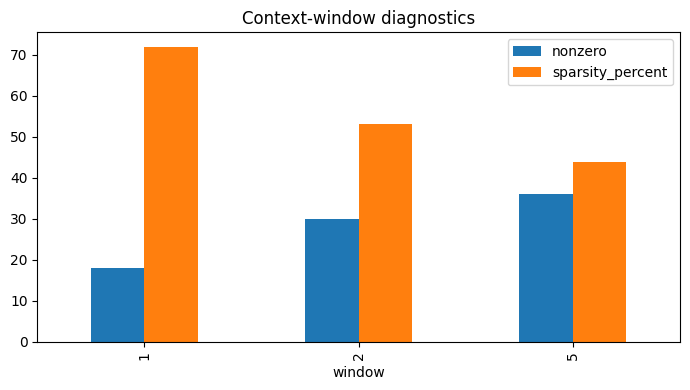

In [6]:
matrix_stats.plot(x='window', y=['nonzero', 'sparsity_percent'], kind='bar', figsize=(7, 4), title='Context-window diagnostics')
plt.tight_layout()
plt.show()

## 6. Word2Vec smoke experiment

This small run checks the standard API on the toy corpus. Replace it with the course corpus for the final experiment and record the full configuration.

In [7]:
try:
    from gensim.models import Word2Vec
    toy_model = Word2Vec(sentences=toy_corpus, vector_size=20, window=2, min_count=1, sg=0, epochs=30, workers=1, seed=42)
    print({'vocabulary_size': len(toy_model.wv), 'vector_size': toy_model.vector_size, 'window': toy_model.window, 'epochs': toy_model.epochs})
    print(toy_model.wv.most_similar('cat', topn=3))
except Exception as exc:
    print('Word2Vec smoke test unavailable:', type(exc).__name__, str(exc))

{'vocabulary_size': 8, 'vector_size': 20, 'window': 2, 'epochs': 30}
[('meat', 0.17021694779396057), ('eats', 0.11731795221567154), ('milk', 0.0810222178697586)]


## 7. Hyperparameter record

Use the same corpus, seed, epochs, and minimum count when comparing windows 2/5/10 and dimensions 50/100/300.

In [8]:
config_grid = pd.DataFrame([
    {'window': w, 'vector_size': d, 'min_count': 1, 'epochs': 20, 'objective': 'CBOW', 'sentences': len(toy_corpus)}
    for w in (2, 5, 10) for d in (50, 100, 300)
])
config_grid

,window,vector_size,min_count,epochs,objective,sentences
0,2,50,1,20,CBOW,4
1,2,100,1,20,CBOW,4
2,2,300,1,20,CBOW,4
3,5,50,1,20,CBOW,4
4,5,100,1,20,CBOW,4
5,5,300,1,20,CBOW,4
6,10,50,1,20,CBOW,4
7,10,100,1,20,CBOW,4
8,10,300,1,20,CBOW,4


## 8. Evaluation and CSV export

Store raw measurements first; write interpretations in the student-authored report sections.

In [9]:
evaluation_rows = []
for left, right in [('cat', 'dog'), ('cat', 'fish'), ('dog', 'meat')]:
    i, j = word_to_id[left], word_to_id[right]
    evaluation_rows.append({'category': 'cooccurrence_similarity', 'item': f'{left} - {right}', 'window': 1, 'score': cosine_similarity(matrix[i], matrix[j])})
evaluation = pd.DataFrame(evaluation_rows)
evaluation.to_csv('results.csv', mode='a', index=False, header=False)
evaluation

,category,item,window,score
0,cooccurrence_similarity,cat - dog,1,1.000000
1,cooccurrence_similarity,cat - fish,1,0.408248
2,cooccurrence_similarity,dog - meat,1,0.408248


## 9. A slightly larger local corpus

When the course dataset is unavailable, this compact domain corpus keeps the remaining cells executable. Replace `documents` with the assigned dataset before submitting measurements.

In [10]:
documents = [
    'the doctor treated the patient at the hospital',
    'the physician examined the patient and recorded the diagnosis',
    'the clinic provides medical treatment for disease',
    'the nurse prepared the patient for surgery',
    'the doctor and physician discuss the therapy for clinical care',
    'the computer stores medical records and clinical data',
    'the modern computer calculates algorithms and software data',
    'the football team played a match in the stadium',
    'the athlete scored a goal in the football match',
    'the car driver travelled to the city by road',
    'the automobile driver drove the car along the highway',
    'the banana and apple were fresh fruit in the kitchen',
    'the king ruled the royal kingdom with the wise queen',
    'the man and woman walked toward the palace',
    'i deposited money in the financial bank downtown',
    'we sat on the river bank watching the flowing fish',
]
document_sentences = [tokenize(document) for document in documents]
large_vocab, large_index = build_vocabulary(document_sentences, min_count=1)
print('documents:', len(documents), 'vocabulary:', len(large_vocab))


documents: 16 vocabulary: 84


In [11]:
large_matrices = {}
large_stats = []
for width in (1, 2, 5):
    current = build_cooccurrence_matrix(document_sentences, large_vocab, window=width)
    large_matrices[width] = current
    total = len(current) * len(current[0])
    nonzero = sum(value != 0 for row in current for value in row)
    large_stats.append({'window': width, 'vocab_size': len(large_vocab), 'nonzero': nonzero, 'sparsity_percent': round(100 * (1 - nonzero / total), 2)})
pd.DataFrame(large_stats)

,window,vocab_size,nonzero,sparsity_percent
0,1,84,230,96.74
1,2,84,390,94.47
2,5,84,682,90.33


## 10. Query nearest words from the count representation

In [12]:
for query in ('doctor', 'patient', 'computer'):
    print('QUERY:', query)
    print(most_similar(query, large_matrices[2], large_vocab, top_k=5))

QUERY: doctor
[('examined', 0.8249579113843055), ('patient', 0.8249579113843055), ('physician', 0.8006407690254358), ('king', 0.7745966692414834), ('nurse', 0.7745966692414834)]
QUERY: patient
[('doctor', 0.8249579113843055), ('nurse', 0.8215838362577491), ('physician', 0.7925939239012171), ('king', 0.7302967433402214), ('diagnosis', 0.7216878364870323)]
QUERY: computer
[('and', 0.6389151433378876), ('king', 0.5962847939999439), ('nurse', 0.5962847939999439), ('clinic', 0.5773502691896257), ('doctor', 0.5773502691896257)]


## 11. Word2Vec window and dimension sweep

The sweep is guarded so the notebook remains usable when `gensim` is not installed.

In [13]:
from time import perf_counter
from gensim.models import Word2Vec
try:
    sweep_models = {}
    sweep_records = []
    for width in (2, 5, 10):
        for dimension in (50, 100, 300):
            start = perf_counter()
            model = Word2Vec(sentences=document_sentences, vector_size=dimension, window=width, min_count=1, sg=0, epochs=30, workers=1, seed=42)
            elapsed = round(perf_counter() - start, 3)
            sweep_models[(width, dimension)] = model
            sweep_records.append({'window': width, 'vector_size': dimension, 'seconds': elapsed, 'vocab_size': len(model.wv)})
    sweep_df = pd.DataFrame(sweep_records)
    print(sweep_df)
except Exception as exc:
    sweep_models = {}
    print('Sweep unavailable:', type(exc).__name__, str(exc))


   window  vector_size  seconds  vocab_size
0       2           50    0.050          84
1       2          100    0.044          84
2       2          300    0.047          84
3       5           50    0.056          84
4       5          100    0.050          84
5       5          300    0.048          84
6      10           50    0.052          84
7      10          100    0.055          84
8      10          300    0.048          84


In [14]:
if sweep_models:
    pairs = [('doctor', 'physician'), ('doctor', 'hospital'), ('car', 'automobile'), ('computer', 'football'), ('computer', 'banana')]
    rows = []
    for width in (2, 5, 10):
        model = sweep_models[(width, 100)]
        for left, right in pairs:
            score = round(float(model.wv.similarity(left, right)), 4) if (left in model.wv and right in model.wv) else None
            rows.append({'window': width, 'pair': f'{left} - {right}', 'score': score})
    sweep_eval_df = pd.DataFrame(rows)
    print(sweep_eval_df)


    window                 pair   score
0        2   doctor - physician -0.1315
1        2    doctor - hospital -0.0945
2        2     car - automobile  0.1034
3        2  computer - football -0.0559
4        2    computer - banana -0.0681
5        5   doctor - physician -0.1351
6        5    doctor - hospital -0.0911
7        5     car - automobile  0.0969
8        5  computer - football -0.0390
9        5    computer - banana -0.0450
10      10   doctor - physician -0.1325
11      10    doctor - hospital -0.0880
12      10     car - automobile  0.1015
13      10  computer - football -0.0442
14      10    computer - banana -0.0432


## 12. Similarity, analogy, and semantic search API calls

These cells record raw model outputs. The written ranking and explanation should be completed after inspecting the corpus evidence.

In [15]:
if sweep_models:
    final_model = sweep_models[(5, 100)]
    eval_pairs = [('doctor', 'physician'), ('car', 'driver'), ('car', 'automobile'), ('king', 'queen'), ('computer', 'banana')]
    print('Word similarities (window=5, dim=100):')
    for pair in eval_pairs:
        if pair[0] in final_model.wv and pair[1] in final_model.wv:
            print(f'  similarity({pair[0]}, {pair[1]}) = {round(float(final_model.wv.similarity(*pair)), 4)}')
    if all(word in final_model.wv for word in ('king', 'man', 'woman')):
        print('\nAnalogy query: king - man + woman:')
        print(final_model.wv.most_similar(positive=['king', 'woman'], negative=['man'], topn=5))
    print("\nTop-5 most similar to 'doctor':")
    print(final_model.wv.most_similar('doctor', topn=5))


Word similarities (window=5, dim=100):
  similarity(doctor, physician) = -0.1351
  similarity(car, driver) = 0.1769
  similarity(car, automobile) = 0.0969
  similarity(king, queen) = 0.0525
  similarity(computer, banana) = -0.045

Analogy query: king - man + woman:
[('software', 0.2177032083272934), ('were', 0.1996048390865326), ('scored', 0.16646134853363037), ('automobile', 0.1346537321805954), ('along', 0.12993712723255157)]

Top-5 most similar to 'doctor':
[('royal', 0.21415969729423523), ('clinical', 0.14253953099250793), ('the', 0.14135925471782684), ('treated', 0.14090098440647125), ('examined', 0.13287846744060516)]


In [16]:
if sweep_models:
    query_tokens = [word for word in ('medical', 'treatment') if word in final_model.wv]
    query_vector = final_model.wv.get_mean_vector(query_tokens) if query_tokens else None
    if query_vector is not None:
        ranked = []
        for number, document in enumerate(documents):
            tokens = [word for word in tokenize(document) if word in final_model.wv]
            if tokens:
                doc_vector = final_model.wv.get_mean_vector(tokens)
                score = float(cosine_similarity(query_vector, doc_vector))
                ranked.append((number, score, document))
        ranked.sort(key=lambda row: row[1], reverse=True)
        print("Semantic Search for query 'medical treatment':")
        for rank, (num, score, doc) in enumerate(ranked[:3], 1):
            print(f'  Top {rank} [score={score:.4f}]: {doc}')


Semantic Search for query 'medical treatment':
  Top 1 [score=0.6113]: the clinic provides medical treatment for disease
  Top 2 [score=0.2786]: the computer stores medical records and clinical data
  Top 3 [score=0.1879]: the doctor and physician discuss the therapy for clinical care
